In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings


In [14]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [23]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)
df['Age']    = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex']    = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X=df[features]
y=df['Survived']

In [24]:

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
df=RandomForestClassifier(max_depth=4 , random_state=1 , n_estimators=100, n_jobs=-1)
df.fit(X_train,y_train)
df_preds=df.predict(X_test)
df_acc=accuracy_score(y_test,df_preds)

In [26]:
single_tree_acc=[]
for seed in range(10):
  t=DecisionTreeClassifier(max_depth=4,random_state=seed)
  t.fit(X_train,y_train)
  t.preds=t.predict(X_test)
  single_tree_acc.append(accuracy_score(y_test,t.preds))



In [27]:
print(f"\nSingle tree accuracies across 10 random seeds:")
print([f"{a:.4f}" for a in single_tree_acc])
print(f"Single tree variance: {np.var(single_tree_acc):.6f}")
print(f"Random Forest (stable): {df_acc:.4f}")



Single tree accuracies across 10 random seeds:
['0.7989', '0.7989', '0.7989', '0.7989', '0.7989', '0.7989', '0.7989', '0.7989', '0.7989', '0.7989']
Single tree variance: 0.000000
Random Forest (stable): 0.8156


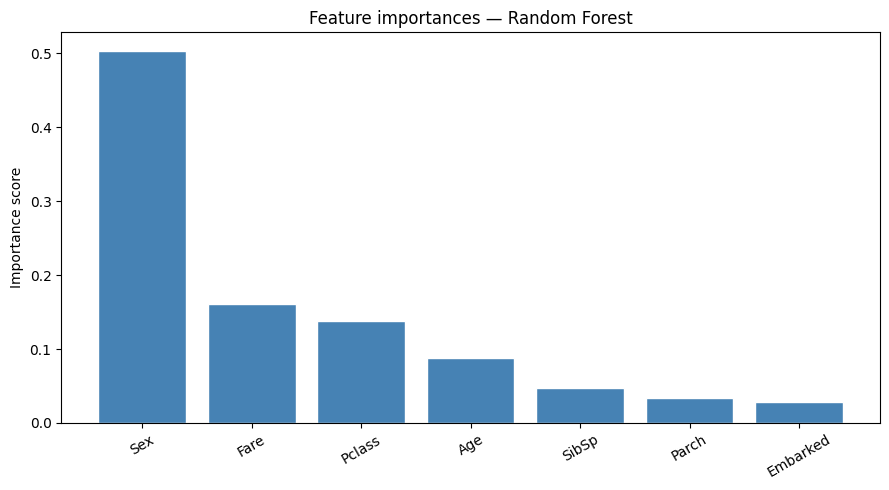

In [29]:
importances = df.feature_importances_
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(features)),
        importances[indices],
        color='steelblue', edgecolor='white')
plt.xticks(range(len(features)),
           [features[i] for i in indices], rotation=30)
plt.title('Feature importances — Random Forest')
plt.ylabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()